# Lab Segmentation 2

In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

EXPERIMENT 1: Global Adaptive Thresholding

Processing cameraman.png...
Initial threshold: 119
Iteration 1: T=102, μ1=44.34, μ2=159.69
Iteration 2: T=92, μ1=29.44, μ2=155.21
Iteration 3: T=89, μ1=24.68, μ2=153.69
Iteration 4: T=89, μ1=23.73, μ2=153.35
Final threshold converged: 89



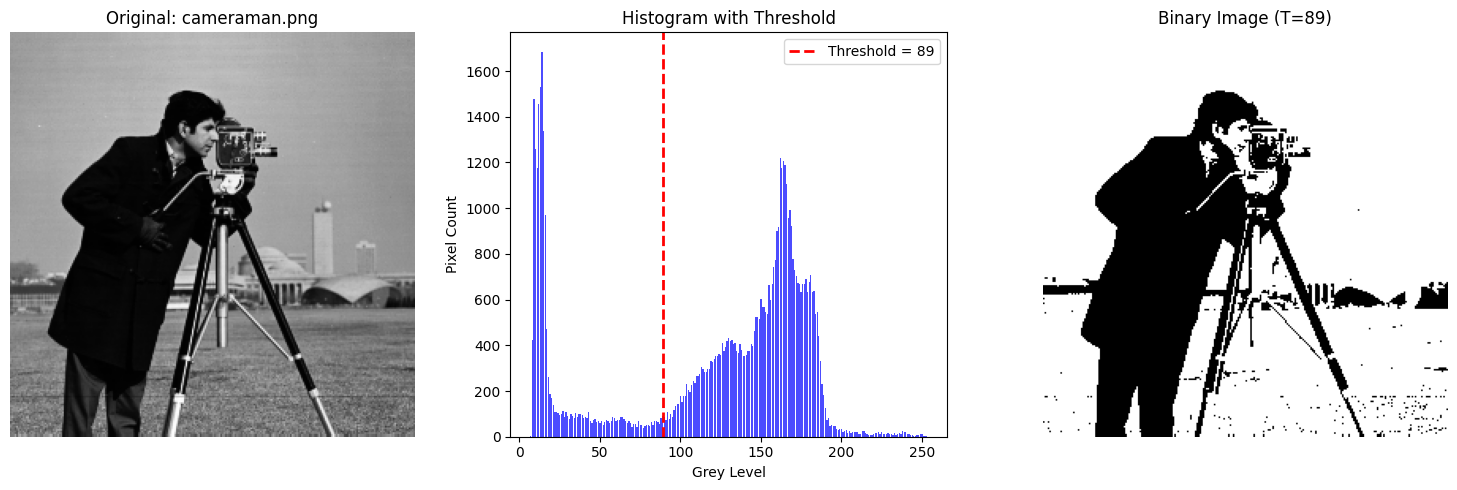


Processing cufe.png...
Initial threshold: 165
Iteration 1: T=152, μ1=96.08, μ2=207.90
Iteration 2: T=145, μ1=85.42, μ2=203.80
Iteration 3: T=143, μ1=82.77, μ2=202.71
Iteration 4: T=142, μ1=82.27, μ2=202.49
Iteration 5: T=142, μ1=82.04, μ2=202.38
Final threshold converged: 142



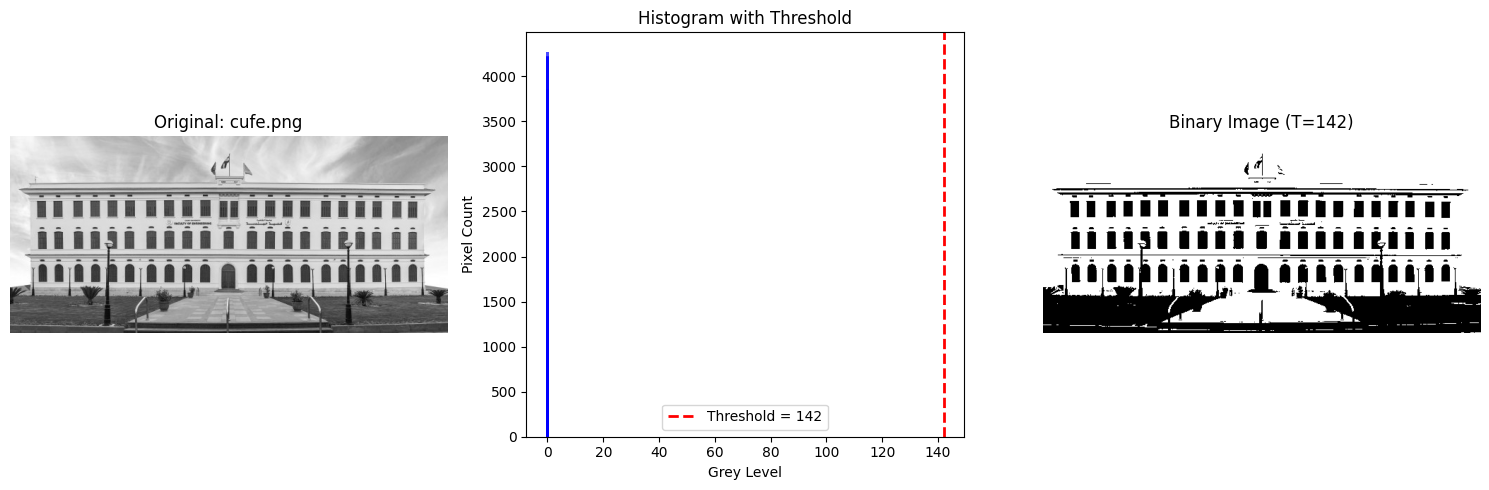


Processing book1.png...
Initial threshold: 156
Iteration 1: T=151, μ1=134.32, μ2=168.25
Iteration 2: T=147, μ1=127.84, μ2=166.45
Iteration 3: T=145, μ1=123.83, μ2=165.49
Iteration 4: T=144, μ1=122.22, μ2=165.11
Iteration 5: T=143, μ1=121.46, μ2=164.93
Iteration 6: T=143, μ1=120.72, μ2=164.75
Final threshold converged: 143



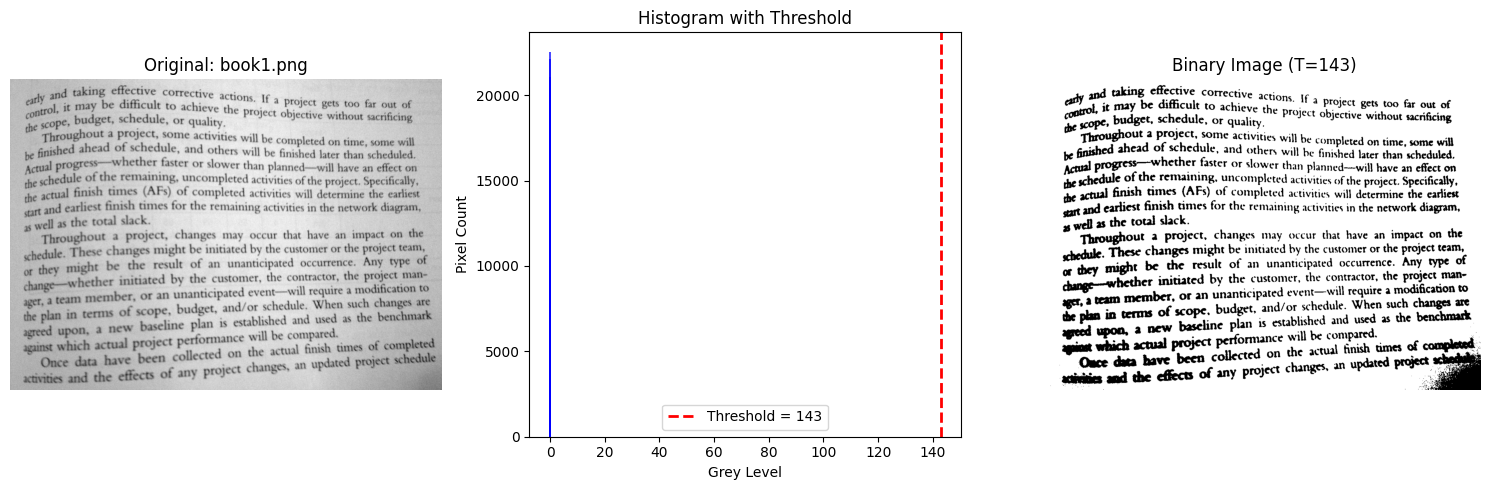


Processing book.png...
Initial threshold: 128
Iteration 1: T=136, μ1=34.19, μ2=237.38
Iteration 2: T=138, μ1=35.74, μ2=239.41
Iteration 3: T=138, μ1=36.07, μ2=239.83
Final threshold converged: 138



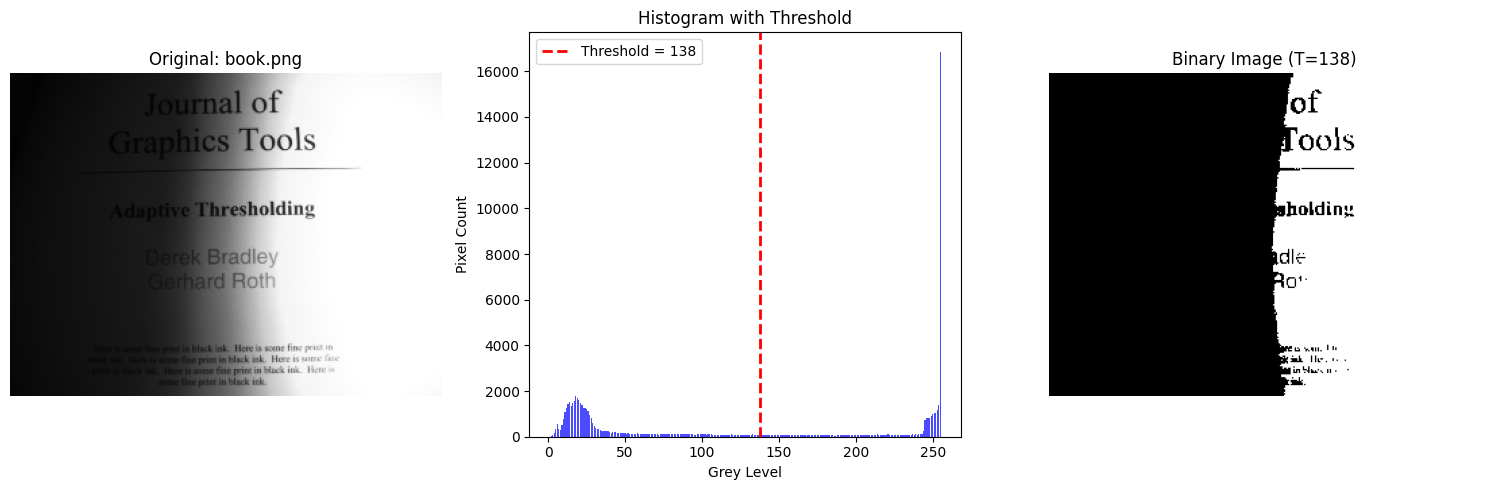


EXPERIMENT 2: Local Adaptive Thresholding

Calculating global threshold for book.png...
Initial threshold: 128
Iteration 1: T=136, μ1=34.19, μ2=237.38
Iteration 2: T=138, μ1=35.74, μ2=239.41
Iteration 3: T=138, μ1=36.07, μ2=239.83
Final threshold converged: 138


Applying local thresholding (2x2 blocks)...
Block [0,0]:
Initial threshold: 27
Iteration 1: T=34, μ1=16.23, μ2=51.62
Iteration 2: T=40, μ1=17.82, μ2=63.03
Iteration 3: T=43, μ1=18.56, μ2=68.29
Iteration 4: T=45, μ1=18.89, μ2=70.55
Iteration 5: T=46, μ1=19.11, μ2=71.92
Iteration 6: T=46, μ1=19.22, μ2=72.60
Final threshold converged: 46

Block [0,1]:
Initial threshold: 224
Iteration 1: T=198, μ1=145.07, μ2=251.71
Iteration 2: T=189, μ1=129.13, μ2=249.11
Iteration 3: T=186, μ1=124.60, μ2=248.14
Iteration 4: T=186, μ1=123.30, μ2=247.83
Final threshold converged: 186

Block [1,0]:
Initial threshold: 32
Iteration 1: T=41, μ1=19.26, μ2=63.27
Iteration 2: T=46, μ1=20.69, μ2=71.71
Iteration 3: T=49, μ1=21.45, μ2=75.69
Iteration 4: T=5

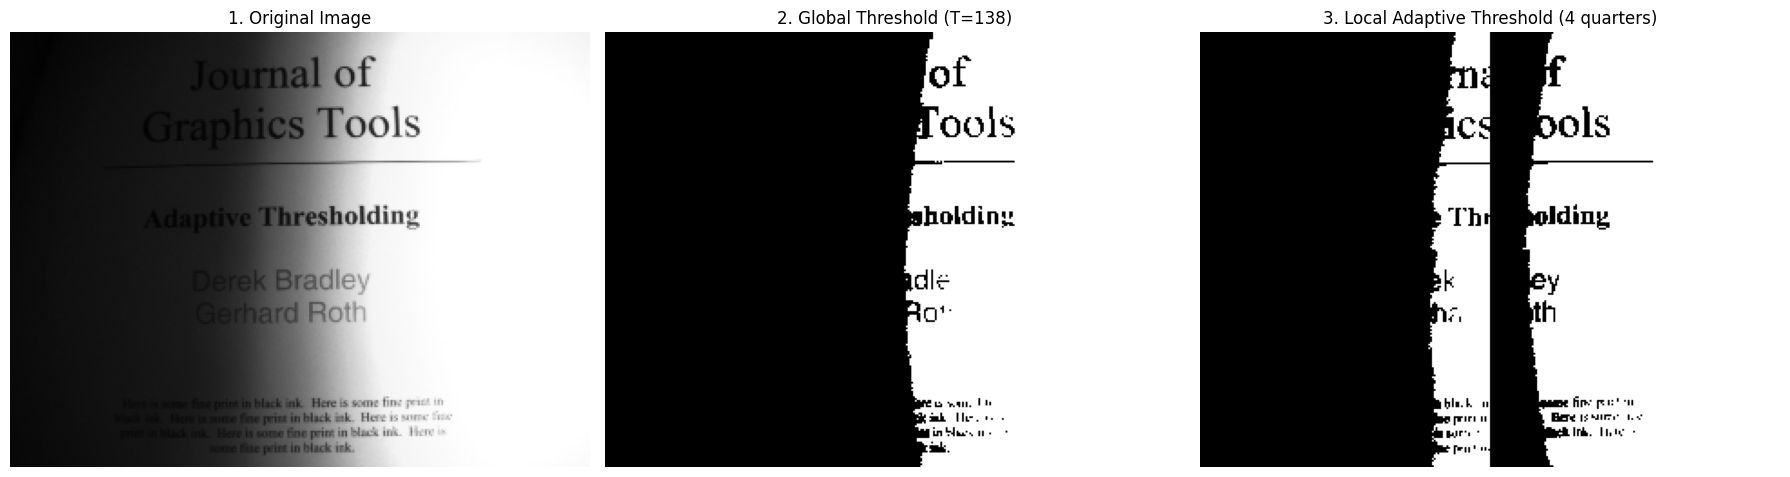


EXPERIMENT 3: Improved Local Thresholding (Bonus)
Initial threshold: 128
Iteration 1: T=136, μ1=34.19, μ2=237.38
Iteration 2: T=138, μ1=35.74, μ2=239.41
Iteration 3: T=138, μ1=36.07, μ2=239.83
Final threshold converged: 138


Applying local thresholding (2x2 blocks)...
Block [0,0]:
Initial threshold: 27
Iteration 1: T=34, μ1=16.23, μ2=51.62
Iteration 2: T=40, μ1=17.82, μ2=63.03
Iteration 3: T=43, μ1=18.56, μ2=68.29
Iteration 4: T=45, μ1=18.89, μ2=70.55
Iteration 5: T=46, μ1=19.11, μ2=71.92
Iteration 6: T=46, μ1=19.22, μ2=72.60
Final threshold converged: 46

Block [0,1]:
Initial threshold: 224
Iteration 1: T=198, μ1=145.07, μ2=251.71
Iteration 2: T=189, μ1=129.13, μ2=249.11
Iteration 3: T=186, μ1=124.60, μ2=248.14
Iteration 4: T=186, μ1=123.30, μ2=247.83
Final threshold converged: 186

Block [1,0]:
Initial threshold: 32
Iteration 1: T=41, μ1=19.26, μ2=63.27
Iteration 2: T=46, μ1=20.69, μ2=71.71
Iteration 3: T=49, μ1=21.45, μ2=75.69
Iteration 4: T=50, μ1=21.90, μ2=77.94
Iteration 5: T=5

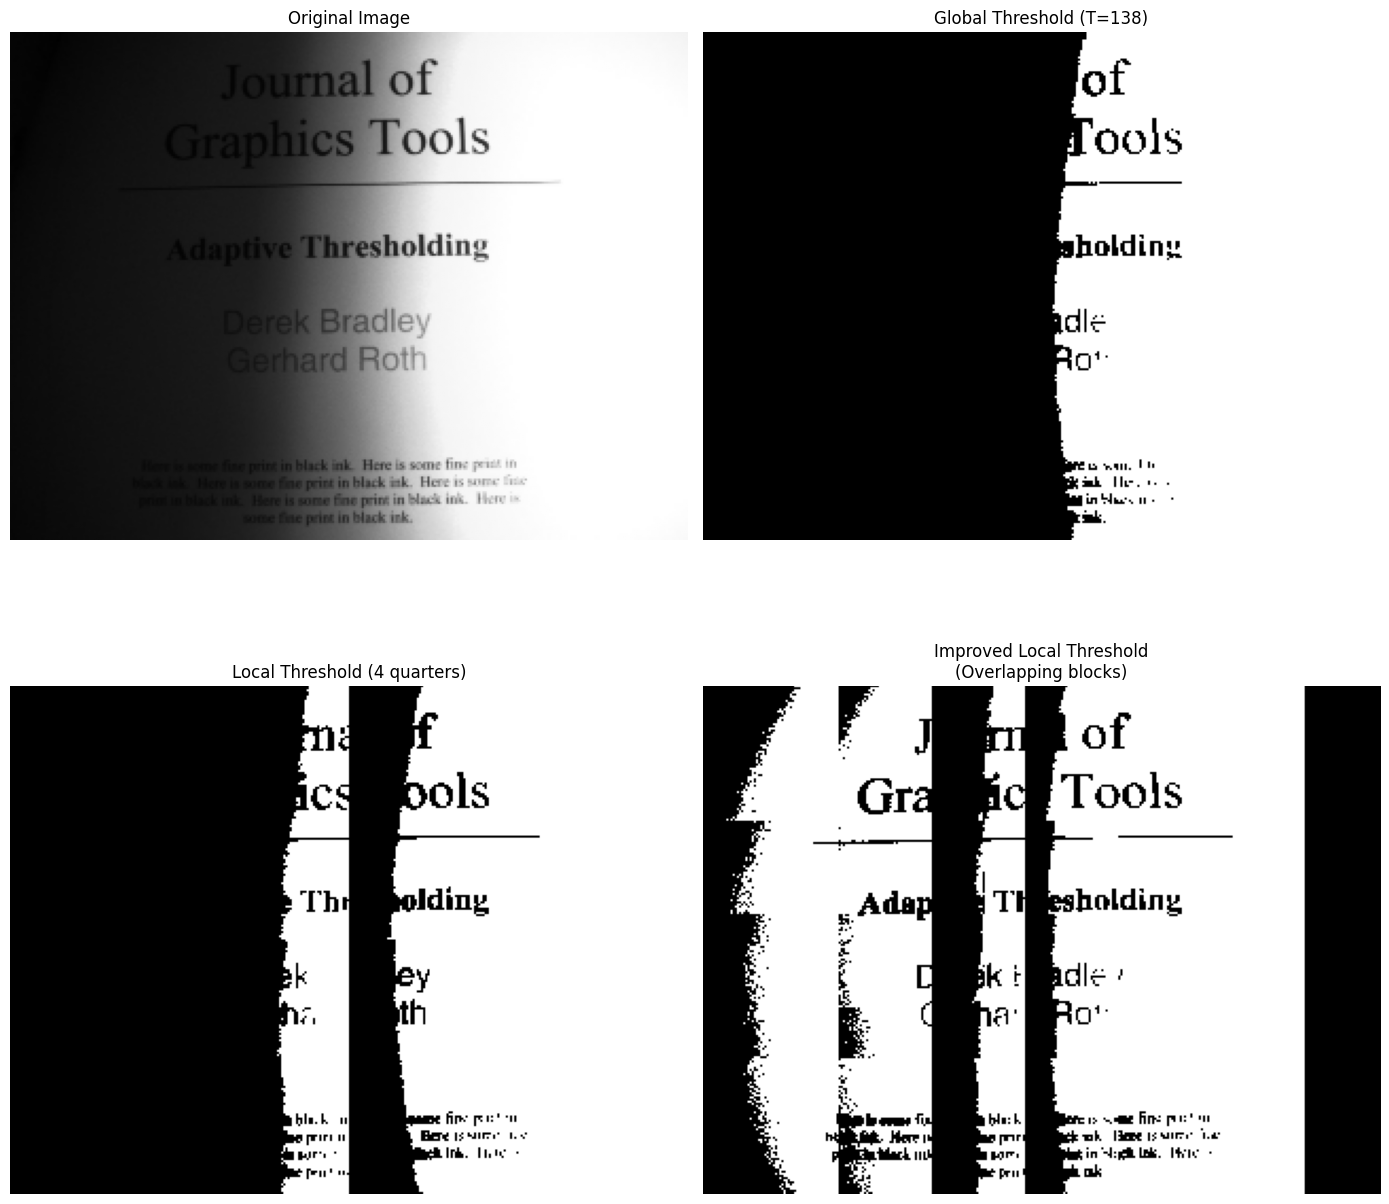

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
from skimage.color import rgb2gray
from skimage.exposure import histogram

# ============= EXPERIMENT 1: Adaptive Thresholding =============

def getThreshold(img):
    """
    Implements histogram-based automatic thresholding using iterative method.
    
    Parameters:
    img: Input grayscale image (normalized 0-1 or uint8)
    
    Returns:
    threshold: Optimal threshold value (0-255)
    """
    # Step 1: Convert to uint8
    if img.dtype != np.uint8:
        img_uint8 = (img * 255).astype('uint8')
    else:
        img_uint8 = img
    
    # Step 2: Get histogram counts - create manual histogram for all 256 levels
    counts = np.zeros(256, dtype=np.int64)
    for pixel_value in range(256):
        counts[pixel_value] = np.sum(img_uint8 == pixel_value)
    
    # Step 3: Calculate initial threshold (weighted mean of all pixels)
    grey_levels = np.arange(256)
    total_pixels = np.sum(counts)
    
    # Calculate Tinit as weighted average
    Tinit = round(np.sum(grey_levels * counts) / total_pixels)
    
    print(f"Initial threshold: {Tinit}")
    
    # Step 4-6: Iterative refinement
    threshold = Tinit
    prev_threshold = -1
    iteration = 0
    
    while threshold != prev_threshold:
        iteration += 1
        prev_threshold = threshold
        
        # Calculate mean of lower group (grey levels < threshold)
        lower_indices = list(range(0, threshold))
        lower_counts = counts[lower_indices]
        lower_sum = np.sum(np.array(lower_indices) * lower_counts)
        lower_total = np.sum(lower_counts)
        
        if lower_total > 0:
            mean_lower = lower_sum / lower_total
        else:
            mean_lower = 0
        
        # Calculate mean of higher group (grey levels >= threshold)
        higher_indices = list(range(threshold, 256))
        higher_counts = counts[higher_indices]
        higher_sum = np.sum(np.array(higher_indices) * higher_counts)
        higher_total = np.sum(higher_counts)
        
        if higher_total > 0:
            mean_higher = higher_sum / higher_total
        else:
            mean_higher = 255
        
        # Update threshold as average of two means
        threshold = round((mean_lower + mean_higher) / 2)
        
        print(f"Iteration {iteration}: T={threshold}, μ1={mean_lower:.2f}, μ2={mean_higher:.2f}")
    
    print(f"Final threshold converged: {threshold}\n")
    return threshold


def apply_threshold(img, threshold):
    """
    Apply binary thresholding to an image.
    
    Parameters:
    img: Input image
    threshold: Threshold value (0-255)
    
    Returns:
    Binary image (0 or 255)
    """
    if img.dtype != np.uint8:
        img_uint8 = (img * 255).astype('uint8')
    else:
        img_uint8 = img
    
    binary_img = np.zeros_like(img_uint8)
    binary_img[img_uint8 >= threshold] = 255
    
    return binary_img


def experiment1(image_names):
    """
    Run Experiment 1: Global adaptive thresholding on multiple images.
    """
    print("=" * 60)
    print("EXPERIMENT 1: Global Adaptive Thresholding")
    print("=" * 60)
    
    for img_name in image_names:
        print(f"\nProcessing {img_name}...")
        
        # Load image
        img = io.imread(img_name)
        
        # Convert to grayscale if needed
        if img.ndim == 3:
            img_gray = rgb2gray(img)
        else:
            img_gray = img
        
        # Get threshold
        T = getThreshold(img_gray)
        
        # Apply threshold
        img_binary = apply_threshold(img_gray, T)
        
        # Display results
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(img_gray, cmap='gray')
        axes[0].set_title(f'Original: {img_name}')
        axes[0].axis('off')
        
        # Show histogram with threshold line
        hist_counts, hist_bins = histogram(img_gray, nbins=256)
        axes[1].bar(hist_bins.astype(np.uint8), hist_counts, width=0.8, color='blue', alpha=0.7)
        axes[1].axvline(x=T, color='red', linestyle='--', linewidth=2, label=f'Threshold = {T}')
        axes[1].set_title('Histogram with Threshold')
        axes[1].set_xlabel('Grey Level')
        axes[1].set_ylabel('Pixel Count')
        axes[1].legend()
        
        axes[2].imshow(img_binary, cmap='gray')
        axes[2].set_title(f'Binary Image (T={T})')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()


# ============= EXPERIMENT 2: Local Adaptive Thresholding =============

def local_adaptive_threshold(img, num_rows=2, num_cols=2):
    """
    Apply local adaptive thresholding by dividing image into blocks.
    
    Parameters:
    img: Input grayscale image
    num_rows: Number of row divisions
    num_cols: Number of column divisions
    
    Returns:
    result: Binary image with local thresholds applied
    """
    if img.dtype != np.uint8:
        img_uint8 = (img * 255).astype('uint8')
    else:
        img_uint8 = img
    
    height, width = img_uint8.shape
    block_height = height // num_rows
    block_width = width // num_cols
    
    result = np.zeros_like(img_uint8)
    
    print(f"\nApplying local thresholding ({num_rows}x{num_cols} blocks)...")
    
    for i in range(num_rows):
        for j in range(num_cols):
            # Define block boundaries
            row_start = i * block_height
            row_end = (i + 1) * block_height if i < num_rows - 1 else height
            col_start = j * block_width
            col_end = (j + 1) * block_width if j < num_cols - 1 else width
            
            # Extract block
            block = img_uint8[row_start:row_end, col_start:col_end]
            
            # Get threshold for this block
            print(f"Block [{i},{j}]:")
            T_local = getThreshold(block / 255.0)
            
            # Apply threshold to block
            result[row_start:row_end, col_start:col_end] = apply_threshold(block, T_local)
    
    return result


def experiment2(image_name='book.png'):
    """
    Run Experiment 2: Local adaptive thresholding (4 quarters).
    """
    print("\n" + "=" * 60)
    print("EXPERIMENT 2: Local Adaptive Thresholding")
    print("=" * 60)
    
    # Load image
    img = io.imread(image_name)
    
    # Convert to grayscale if needed
    if img.ndim == 3:
        img_gray = rgb2gray(img)
    else:
        img_gray = img
    
    # Global threshold
    print(f"\nCalculating global threshold for {image_name}...")
    T_global = getThreshold(img_gray)
    img_global = apply_threshold(img_gray, T_global)
    
    # Local threshold (4 quarters)
    img_local = local_adaptive_threshold(img_gray, num_rows=2, num_cols=2)
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title('1. Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(img_global, cmap='gray')
    axes[1].set_title(f'2. Global Threshold (T={T_global})')
    axes[1].axis('off')
    
    axes[2].imshow(img_local, cmap='gray')
    axes[2].set_title('3. Local Adaptive Threshold (4 quarters)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_gray, img_global, img_local


# ============= EXPERIMENT 3: Improved Local Thresholding (Bonus) =============

def improved_local_threshold(img, block_size=64, overlap=0.25):
    """
    Improved local thresholding with overlapping blocks and smoothing.
    
    Parameters:
    img: Input grayscale image
    block_size: Size of square blocks
    overlap: Overlap ratio between adjacent blocks (0-1)
    
    Returns:
    result: Binary image with improved local thresholding
    
    Justification:
    - Uses overlapping blocks to reduce boundary artifacts
    - Applies weighted averaging in overlap regions
    - Smaller block sizes for more local adaptation
    """
    if img.dtype != np.uint8:
        img_uint8 = (img * 255).astype('uint8')
    else:
        img_uint8 = img
    
    height, width = img_uint8.shape
    step = int(block_size * (1 - overlap))
    
    result = np.zeros((height, width), dtype=np.float32)
    weight_map = np.zeros((height, width), dtype=np.float32)
    
    print(f"\nImproved local thresholding (block_size={block_size}, overlap={overlap})...")
    
    block_count = 0
    for i in range(0, height - block_size + 1, step):
        for j in range(0, width - block_size + 1, step):
            # Extract block
            block = img_uint8[i:i+block_size, j:j+block_size]
            
            # Get threshold
            T_local = getThreshold(block / 255.0)
            
            # Apply threshold
            block_binary = apply_threshold(block, T_local)
            
            # Add to result with weights
            result[i:i+block_size, j:j+block_size] += block_binary
            weight_map[i:i+block_size, j:j+block_size] += 1
            
            block_count += 1
    
    # Average overlapping regions
    result = result / np.maximum(weight_map, 1)
    result = (result > 127).astype(np.uint8) * 255
    
    print(f"Processed {block_count} overlapping blocks")
    
    return result


def experiment3(image_name='book.png'):
    """
    Run Experiment 3: Improved local adaptive thresholding (Bonus).
    """
    print("\n" + "=" * 60)
    print("EXPERIMENT 3: Improved Local Thresholding (Bonus)")
    print("=" * 60)
    
    # Load image
    img = io.imread(image_name)
    
    # Convert to grayscale if needed
    if img.ndim == 3:
        img_gray = rgb2gray(img)
    else:
        img_gray = img
    
    # Global threshold
    T_global = getThreshold(img_gray)
    img_global = apply_threshold(img_gray, T_global)
    
    # Standard local threshold
    img_local = local_adaptive_threshold(img_gray, num_rows=2, num_cols=2)
    
    # Improved local threshold
    img_improved = improved_local_threshold(img_gray, block_size=64, overlap=0.3)
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_global, cmap='gray')
    axes[0, 1].set_title(f'Global Threshold (T={T_global})')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(img_local, cmap='gray')
    axes[1, 0].set_title('Local Threshold (4 quarters)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_improved, cmap='gray')
    axes[1, 1].set_title('Improved Local Threshold\n(Overlapping blocks)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


# ============= MAIN EXECUTION =============

if __name__ == "__main__":
    test_images = ['cameraman.png', 'cufe.png', 'book1.png', 'book.png']
    experiment1(test_images)
    experiment2('book.png')
    experiment3('book.png')
    
 